<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/CIC_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File 'Obfuscated-MalMem2022_Cleaned (2).csv' not found in Colab runtime.
Please select and upload your CSV file:


Saving Obfuscated-MalMem2022_Cleaned (2).csv to Obfuscated-MalMem2022_Cleaned (2).csv

             XGBoost Confusion Matrix Counts               
                                      Metric Component  Count
      True Positives (TP - Malware correctly detected)   5759
     True Negatives (TN - Benign correctly identified)   5847
False Positives (FP - Benign misclassified as Malware)      0
                 False Negatives (FN - Malware missed)      0

             XGBoost Model Performance Metrics             
                                            Metric    Value
True Positive Rate (TPR / Detection Rate / Recall) 1.000000
                         False Positive Rate (FPR) 0.000000
                                    Total Accuracy 1.000000
                                 Balanced Accuracy 1.000000
                                         Precision 1.000000
                                          F1-score 1.000000
                           Geometric Mean (G-Mean) 1.000000
  

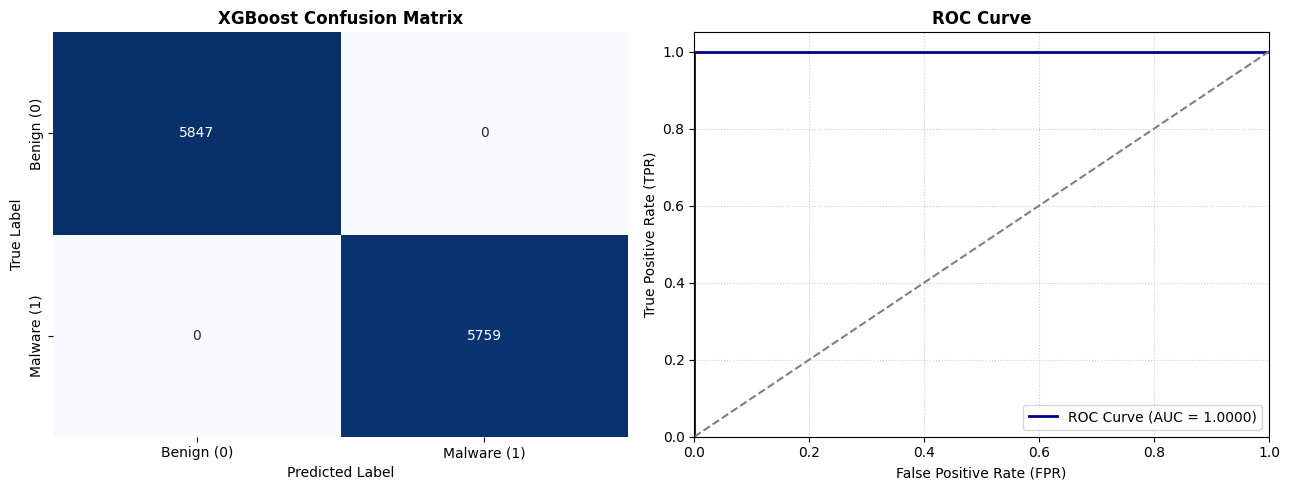

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    roc_curve
)
import xgboost as xgb

# ---------------------------------------------------------
# 1. Load Dataset (Handles missing file automatically)
# ---------------------------------------------------------
file_name = 'Obfuscated-MalMem2022_Cleaned (2).csv'

if not os.path.exists(file_name):
    from google.colab import files
    print(f"File '{file_name}' not found in Colab runtime.")
    print("Please select and upload your CSV file:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# Separate features and target label
X = df.drop(columns=['Class'])
y = df['Class'].map({'Benign': 0, 'Malware': 1})

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 2. Train XGBoost Model
# ---------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. Clean Model Evaluation & Metrics
# ---------------------------------------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Extract Confusion Matrix values
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculated Metrics
tpr = tp / (tp + fn)                          # TPR / Detection Rate / Recall
tnr = tn / (tn + fp)                          # Specificity / TNR
fpr = fp / (fp + tn)                          # False Positive Rate
total_acc = accuracy_score(y_test, y_pred)    # Total Accuracy
bal_acc = balanced_accuracy_score(y_test, y_pred) # Balanced Accuracy
precision = precision_score(y_test, y_pred)   # Precision
f1 = f1_score(y_test, y_pred)                 # F1-score
g_mean = np.sqrt(tpr * tnr)                  # Geometric Mean
roc_auc = roc_auc_score(y_test, y_proba)      # ROC-AUC Score

# ---------------------------------------------------------
# 4. Adversarial Robustness Evaluation
# ---------------------------------------------------------
np.random.seed(42)
feature_std = X_test.std(axis=0).values
epsilon = 0.15

# Perturb features using std-scaled normal distribution
X_test_adv = X_test + np.random.normal(0, epsilon, X_test.shape) * feature_std
y_pred_adv = model.predict(X_test_adv)

robust_acc = accuracy_score(y_test, y_pred_adv)
adv_robustness_score = robust_acc / total_acc if total_acc > 0 else 0.0

# ---------------------------------------------------------
# 5. Print Results: Confusion Matrix & Metrics Summary
# ---------------------------------------------------------
cm_summary = pd.DataFrame({
    'Metric Component': [
        'True Positives (TP - Malware correctly detected)',
        'True Negatives (TN - Benign correctly identified)',
        'False Positives (FP - Benign misclassified as Malware)',
        'False Negatives (FN - Malware missed)'
    ],
    'Count': [tp, tn, fp, fn]
})

metrics_summary = pd.DataFrame({
    'Metric': [
        'True Positive Rate (TPR / Detection Rate / Recall)',
        'False Positive Rate (FPR)',
        'Total Accuracy',
        'Balanced Accuracy',
        'Precision',
        'F1-score',
        'Geometric Mean (G-Mean)',
        'ROC-AUC Score',
        'Robust Accuracy (Under Attack)',
        'Adversarial Robustness Score (ARS)'
    ],
    'Value': [
        f"{tpr:.6f}", f"{fpr:.6f}", f"{total_acc:.6f}", f"{bal_acc:.6f}",
        f"{precision:.6f}", f"{f1:.6f}", f"{g_mean:.6f}", f"{roc_auc:.6f}",
        f"{robust_acc:.6f}", f"{adv_robustness_score:.6f}"
    ]
})

print("\n" + "=" * 65)
print("             XGBoost Confusion Matrix Counts               ")
print("=" * 65)
print(cm_summary.to_string(index=False))

print("\n" + "=" * 65)
print("             XGBoost Model Performance Metrics             ")
print("=" * 65)
print(metrics_summary.to_string(index=False))
print("=" * 65)

# ---------------------------------------------------------
# 6. Plot Confusion Matrix Heatmap & ROC Curve
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Benign (0)', 'Malware (1)'],
    yticklabels=['Benign (0)', 'Malware (1)']
)
axes[0].set_title('XGBoost Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC Curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr_arr, tpr_arr, color='darkblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()